<div style = "background-color:#1F3864; padding:25px; border-radius:8px;">
<h1 style="color:white; text-align:center; margin:0;"> Matjar — Exploratory Data Analysis </h1>
<p style="color:#D9E2F3; text-align:center; margin-top:10px; font-size:15px;">
Exploring user behavioral data (views, cart adds, purchases) to understand 
interaction patterns before building the collaborative filtering 
recommendation model.
</p>
</div>

# Matjar Recommendation System — Exploratory Data Analysis

Exploring user behavioral data (`user_events.csv`) — views, cart adds, 
searches, and purchases — to understand interaction patterns before 
building the collaborative filtering recommendation model.

## Goals
- Confirm event type distribution matches expected realistic weighting
- Check product popularity spread (some products should be viewed far more than others)
- Build the weighted user-product interaction matrix that will feed into the recommender

In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">1. Load the Data</h2>
</div>

In [3]:
brands = pd.read_csv("../data/output/brands.csv")
categories = pd.read_csv("../data/output/categories.csv")
daily_product_metrics = pd.read_csv("../data/output/daily_product_metrics.csv")
order_items = pd.read_csv("../data/output/order_items.csv")
orders = pd.read_csv("../data/output/orders.csv")
product_varient = pd.read_csv("../data/output/product_variants.csv")
products = pd.read_csv("../data/output/products.csv")
user_events = pd.read_csv("../data/output/user_events.csv")
users = pd.read_csv("../data/output/users.csv")

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">2. Review Data Structure</h2>
</div>

<div style="background-color:#EDEAE5; padding:10px 15px; border-radius:6px;">
<h3 style="color:#1F3864; text-align:center; margin:0;">2.1 Checking the data types</h3>
</div>

In [4]:
brands.dtypes

id          object
name        object
slug        object
logoUrl    float64
dtype: object

In [5]:
categories.dtypes

id           object
name         object
slug         object
parentId    float64
dtype: object

In [6]:
daily_product_metrics.dtypes

id                object
productId         object
date              object
unitsSold          int64
revenue            int64
avgPrice         float64
viewCount          int64
stockEndOfDay      int64
dtype: object

In [7]:
order_items.dtypes

id           object
orderId      object
variantId    object
quantity      int64
dtype: object

In [8]:
orders.dtypes

id           object
userId       object
status       object
createdAt    object
dtype: object

In [9]:
product_varient.dtypes

id            object
productId     object
sku           object
size          object
color         object
stock          int64
price        float64
dtype: object

In [10]:
products.dtypes

id              object
name            object
slug            object
description     object
categoryId      object
brandId         object
basePrice      float64
createdAt       object
updatedAt       object
dtype: object

In [11]:
user_events.dtypes

id            object
userId        object
sessionId     object
productId     object
eventType     object
metadata     float64
createdAt     object
dtype: object

In [12]:
users.dtypes

id                   object
email                object
passwordHash         object
firstName            object
lastName             object
role                 object
refreshTokenHash    float64
createdAt            object
updatedAt            object
dtype: object

<div style="background-color:#EDCC80; padding:15px; border-radius:8px;">
<h2 style="color:#1F3864; text-align:center; margin:0;">3. Explanatory Data Analysis</h2>
</div>

In [13]:
tables = [daily_product_metrics,order_items,product_varient,products,user_events,users]

In [14]:
numerical_columns = []
for table in tables:
    z = table.select_dtypes(include="number").columns.tolist()
    for col in z:
        numerical_columns.append(col)
numerical_columns

['unitsSold',
 'revenue',
 'avgPrice',
 'viewCount',
 'stockEndOfDay',
 'quantity',
 'stock',
 'price',
 'basePrice',
 'metadata',
 'refreshTokenHash']

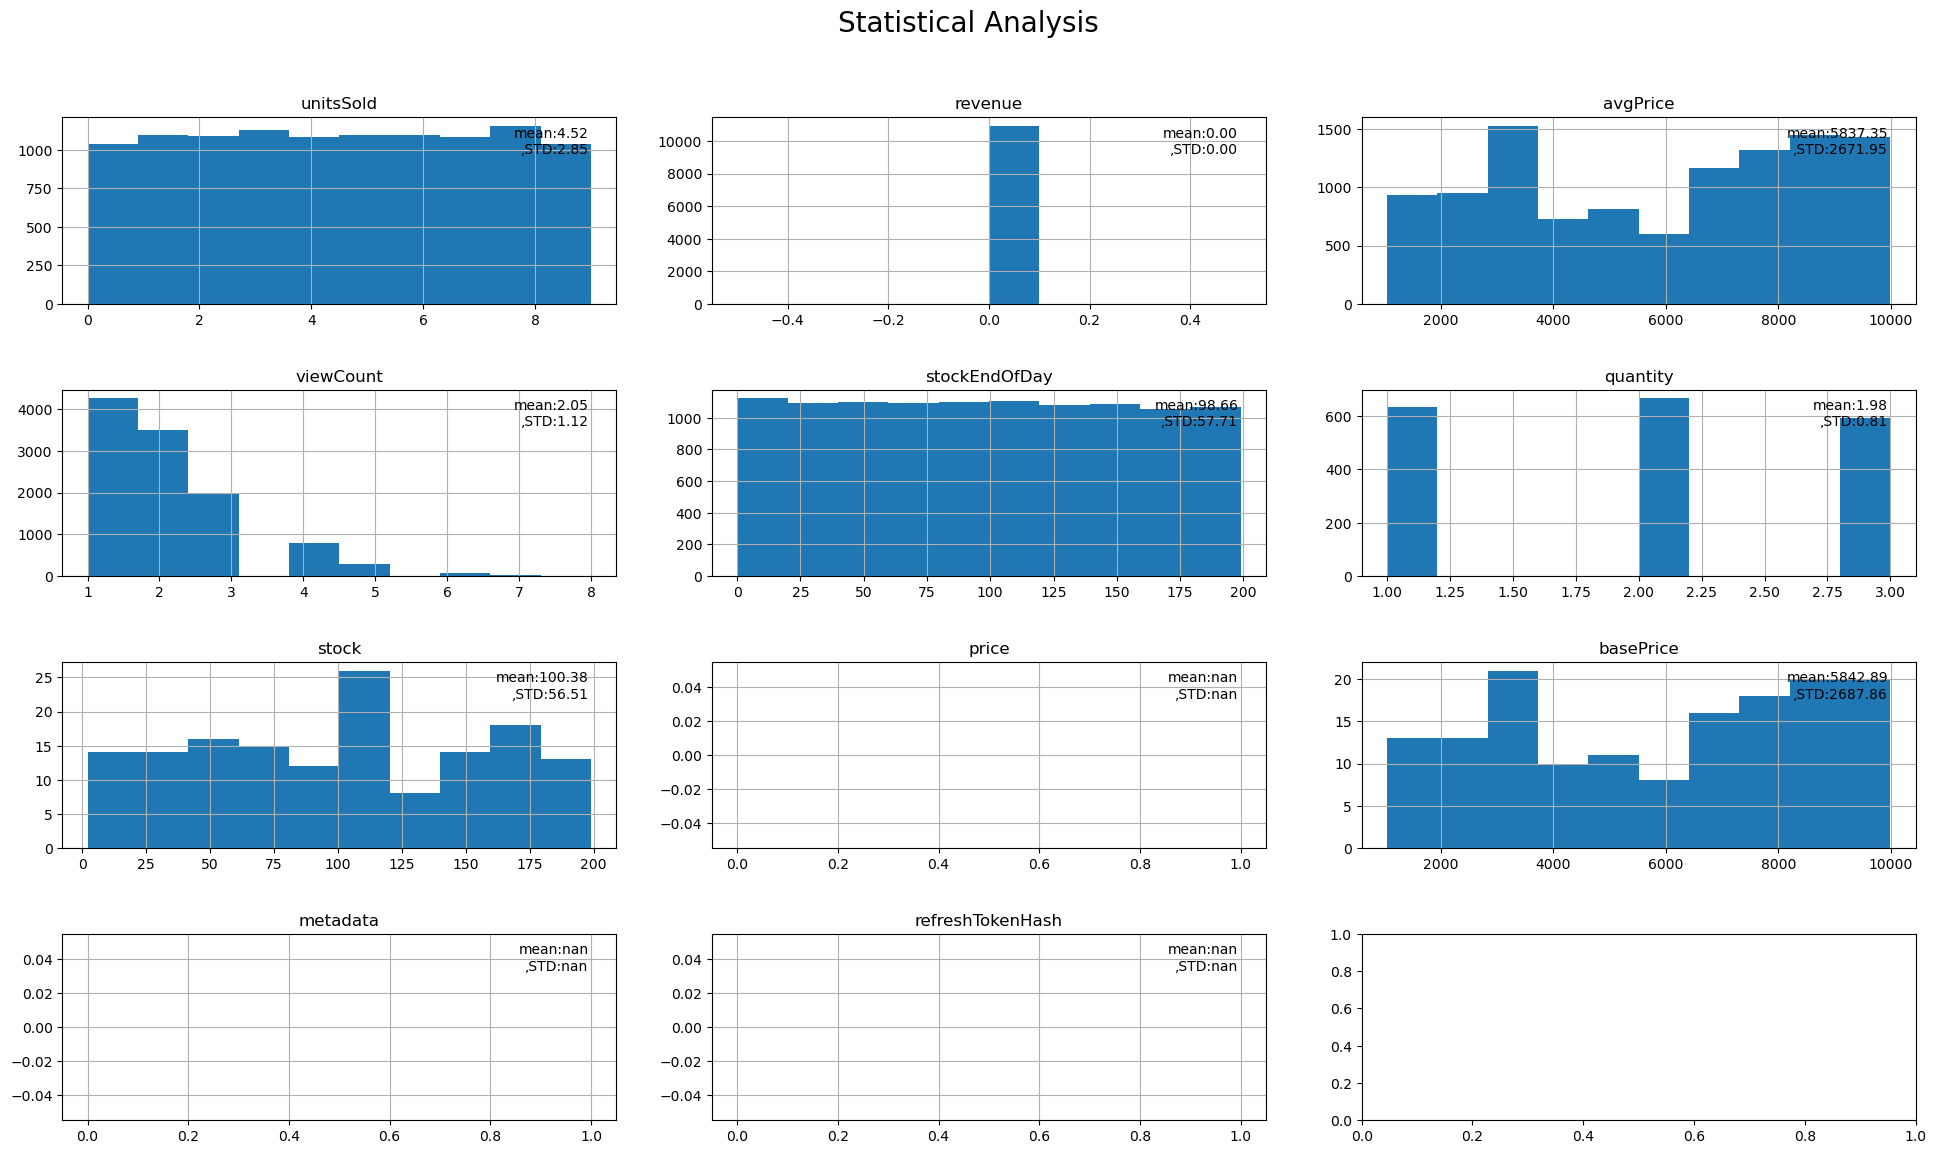

In [51]:
fig,ax = plt.subplots(4,3,figsize=(20,12))
ax = ax.flatten()

for i,column in enumerate(numerical_columns):
    for table in tables :
        if column in table.columns:
            table[column].hist(ax=ax[i])
            mean = table[column].mean()
            std= table[column].std()
            ax[i].set_title(column)
            ax[i].text(0.95,0.95,f"mean:{mean:.2f}\n,STD:{std:.2f}",
                        va = "top" , ha = "right",transform = ax[i].transAxes)
            break

plt.suptitle("Statistical Analysis",fontsize=20)

plt.tight_layout(pad = 3.0)
plt.show()

## Numeric Column Distributions — Observations

**Working as expected:**
- **`unitsSold`** — fairly even spread from 0-9, mean ~4.5. Reasonable, though 
  fully uniform (random placeholder values, not derived from real order data).
- **`viewCount`** — right-skewed, most days/products have 1-3 views, dropping 
  off sharply after that. This is the one distribution that reflects real 
  aggregated behavior (built from actual `user_events` VIEW rows), and the 
  skew looks realistic.
- **`stockEndOfDay`** and **`stock`** — both roughly uniform across 0-200, 
  as expected from `np.random.randint(0, 200)`.
- **`avgPrice`** and **`basePrice`** — spread across the 1,000-10,000 range, 
  as expected from `np.random.uniform(1000, 10000)`. Same distribution shape 
  in both (expected, since `avgPrice` was pulled directly from `basePrice`).
- **`quantity`** — only three discrete values (1, 2, 3), matching 
  `np.random.randint(1, 4)`, roughly evenly split.

**Flagged as placeholder / needs revisiting:**
- **`revenue`** — flat at 0 for every row (mean: 0.00, STD: 0.00). This was 
  set as a hardcoded placeholder during generation, never actually computed 
  from `unitsSold × avgPrice`. Needs fixing before this field is useful for 
  the forecasting model.
- **`price`** — empty entirely (mean: NaN). Every `ProductVariant.price` was 
  set to `None` by design (falls back to `Product.basePrice`), so this 
  column has no data to plot. Expected, not a bug.

## Takeaway
Most distributions match the generation logic as designed. Two follow-ups 
before forecasting model training: (1) compute real `revenue` values instead 
of the placeholder 0, and (2) decide whether `price` should stay empty or be 
dropped from forecasting features, since it's structurally always null in 
this dataset.